# 04 — Baselines: Popularity and Item-kNN

## Why this matters

Every model in notebooks 5-6 needs a floor to beat, or its complexity isn't justified. A
non-personalized popularity ranking is the cheapest possible recommender — same list for
everyone — and a neighborhood model (item-kNN) is the cheapest *personalized* one. If matrix
factorization or a neural two-tower can't clear both of these by a meaningful margin, they're
not earning their extra training cost and complexity.

In [1]:
import numpy as np

from groovn.data import build_interaction_matrix, load_filtered_split
from groovn.evaluation import build_ground_truth, warm_user_rows
from groovn.metrics import evaluate_rankings
from groovn.ranking import top_k_excluding_seen
from groovn.baselines import ItemKNNRecommender, PopularityRecommender

RANDOM_STATE = 42
K = 10

train, test, cutoff = load_filtered_split()
matrix, user_index, item_index = build_interaction_matrix(train, value_col="rating")
warm_rows = warm_user_rows(test, user_index)
ground_truth = build_ground_truth(test, user_index, item_index)
n_items = matrix.shape[1]
print(f"{matrix.shape[0]:,} train users, {n_items:,} train items, {len(warm_rows):,} warm test users")

111,261 train users, 82,723 train items, 39,843 warm test users


This is exactly the setup validated in notebook 3 — same split, same filtering, same warm
users and ground truth — loaded through `groovn.data.load_filtered_split` instead of
rebuilt by hand, so there's no chance of a silent mismatch between notebooks.

## Popularity

Rank every item by total train-period interaction count; recommend the most popular items a
user hasn't already interacted with. No per-user personalization at all — it's the same
ranked list for everyone, just masked differently. `PopularityRecommender` and the shared
`top_k_excluding_seen` helper (notebook 3's masking logic, reused rather than reimplemented)
do the work.

In [2]:
popularity = PopularityRecommender().fit(matrix)
pop_scores = popularity.scores()
pop_top_k = top_k_excluding_seen(pop_scores, matrix, warm_rows, K)
pop_rankings = {u: list(row[row >= 0]) for u, row in zip(warm_rows, pop_top_k)}

pop_metrics = evaluate_rankings(pop_rankings, ground_truth, K, n_items)
pop_metrics

{'recall@10': 0.0022563184955245678,
 'ndcg@10': 0.0019340277779490995,
 'coverage@10': 0.00020550511949518272,
 'n_users_evaluated': 32384}

**Reading the result:** coverage@10 is ~0.02% of the catalog — across 32,384 users, the top-10
lists only ever contain a few dozen distinct albums total. That's the Lorenz-curve
concentration from notebook 1 showing up directly in model behavior: a handful of albums are
so dominant that they crowd out everything else for nearly every user, regardless of their
individual history. Recall/NDCG are low but non-zero: some fraction of users really do go on
to interact with whatever's broadly popular.

## Item-kNN

Score item `i` for user `u` by summing the similarity between `i` and every item `u` already
interacted with. This *is* personalized — two users with different histories get different
scores for the same item — using only co-interaction patterns, no latent model to train.
`ItemKNNRecommender` builds a sparse, truncated (top-50 neighbors per item) cosine similarity
graph via `sklearn.neighbors.NearestNeighbors` rather than a dense item-item matrix, which at
this catalog size (82,723 items) would need ~54GB to hold densely.

In [3]:
item_knn = ItemKNNRecommender(n_neighbors=50).fit(matrix)
knn_scores = item_knn.scores()
knn_top_k = top_k_excluding_seen(knn_scores, matrix, warm_rows, K, batch_size=2000)
knn_rankings = {u: list(row[row >= 0]) for u, row in zip(warm_rows, knn_top_k)}

knn_metrics = evaluate_rankings(knn_rankings, ground_truth, K, n_items)
knn_metrics

{'recall@10': 0.015568311366263441,
 'ndcg@10': 0.011890766990109032,
 'coverage@10': 0.7948454480616032,
 'n_users_evaluated': 32384}

**Reading the result:** item-kNN roughly **7x's popularity's recall@10** (0.0156 vs. 0.0023)
and **NDCG@10** (0.0119 vs. 0.0019), while also jumping coverage@10 from ~0.02% to ~79% of the
catalog. Both numbers move together for an intuitive reason: once recommendations are based
on *what this specific user* interacted with rather than global popularity, different users
pull in different corners of the catalog — personalization and catalog coverage aren't
competing goals here, popularity's lack of either comes from the same root cause (one global
ranking for everyone).

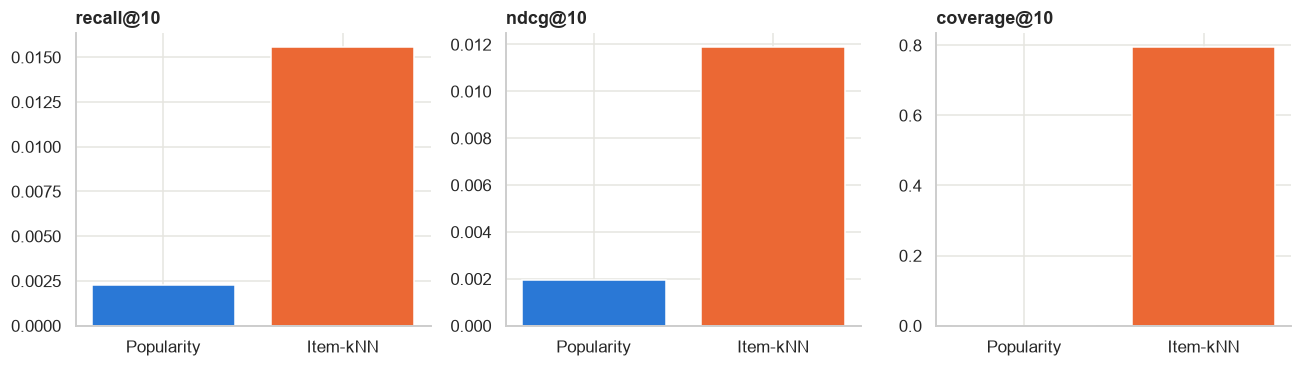

In [4]:
import matplotlib.pyplot as plt

import viz

viz.style()
results = {"Popularity": pop_metrics, "Item-kNN": knn_metrics}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
for ax, metric in zip(axes, [f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]):
    values = [results[name][metric] for name in results]
    ax.bar(list(results), values, color=viz.CATEGORICAL[:2])
    viz.label(ax, metric)
plt.tight_layout()
plt.show()

## Handing off

`popularity.scores()` returns a 1D vector; `item_knn.scores()` returns a sparse
`(n_users, n_items)` matrix — both are valid inputs to `top_k_excluding_seen`, and the
dense-score outputs from matrix factorization and the two-tower model in notebooks 5-6 slot
into the exact same call via the callable form. Baseline numbers (`pop_metrics`,
`knn_metrics`) are recomputed fresh in notebook 7's final comparison table rather than copied
by hand.